# AutoEIT — Inter-rater agreement: how much of the ASR error is a human noise floor?

Every ASR system so far (`analyze_transcription_quality_v2_filtered.ipynb`,
`analyze_resegmented_transcription_quality.ipynb`) has been scored against **each human rater
separately**, but the two raters' transcriptions have never been scored against *each other*. A
mean WER of ~0.25 for the best ASR system is uninterpretable in isolation — is that close to how
much two trained humans naturally disagree on transcribing the same disfluent, accented L2 speech,
or is it much worse than that? This notebook computes that floor directly.

`src/postprocessing/build_postprocessed_csv.py`'s `build_rows()` now also computes `human_wer`,
`human_mer`, `human_cer` per sentence (rater1 as reference, rater2 as hypothesis — same
normalization as every other score: lowercase, punctuation stripped). Unlike ASR-vs-human scoring,
this doesn't depend on the rank-based item↔Sentence alignment that's only trustworthy for "hit"
recordings (exactly 30 ASR items) — both texts come from the same Excel row — so it's available for
**every** recording with a matched human-transcription sheet, not just hits: 187 of 188 recordings
for the original segmentation's postprocessing snapshot (`data/postprocessed/v2/`).

**Caveat:** WER/MER aren't symmetric (insertions vs. deletions swap depending on which side is the
reference), so `human_wer` using rater1-as-reference isn't identical to what you'd get scoring
rater2-as-reference — but for two independently-produced transcriptions of the same short utterance
the difference should be small; not double-checked here.

## Config

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

In [2]:
V2_ROOT = Path("../../data/postprocessed/v2")
RESEGMENTED_ROOT = Path("../../data/postprocessed/resegmented")
VERSIONS = ["version_a", "version_b"]
METRICS = ["wer", "mer", "cer"]

v2_hit_recordings = set(Path("../../data/transcribed_v2_hit_recordings.txt").read_text(encoding="utf-8").split())
resegmented_hit_recordings = set(Path("../../data/resegmented_hit_recordings.txt").read_text(encoding="utf-8").split())
print(f"v2 hit recordings: {len(v2_hit_recordings)}, resegmented hit recordings: {len(resegmented_hit_recordings)}")

v2 hit recordings: 84, resegmented hit recordings: 102


## Load inter-rater scores

One row per (recording, sentence) with a non-null `human_wer` — i.e. every sentence both raters
transcribed something for, regardless of whether that recording's ASR item count happened to be a
"hit".

In [3]:
def load_human_scores(root: Path, recording_filter: set[str] | None = None) -> pd.DataFrame:
    records = []
    for version in VERSIONS:
        version_dir = root / version
        if not version_dir.exists():
            continue
        for recording_dir in sorted(version_dir.iterdir()):
            if recording_filter is not None and recording_dir.name not in recording_filter:
                continue
            df = pd.read_csv(recording_dir / "transcriptions.csv")
            if "human_wer" not in df.columns:
                continue
            sub = df[["sentence_number", "human_wer", "human_mer", "human_cer"]].dropna()
            for _, row in sub.iterrows():
                records.append({
                    "version": version,
                    "recording": recording_dir.name,
                    "sentence_number": row["sentence_number"],
                    "wer": row["human_wer"],
                    "mer": row["human_mer"],
                    "cer": row["human_cer"],
                })
    return pd.DataFrame(records)


human_all = load_human_scores(V2_ROOT)
print(f"all recordings with a human sheet match: {len(human_all)} scored sentences, "
      f"{human_all['recording'].nunique()} recordings")

all recordings with a human sheet match: 5415 scored sentences, 182 recordings


## The floor, across every available recording (n≈187)

In [4]:
def summarize(df: pd.DataFrame) -> pd.Series:
    out = df[METRICS].mean().round(4).add_suffix("_mean")
    out = pd.concat([out, df[METRICS].median().round(4).add_suffix("_median")])
    out["wer_pct_perfect"] = round((df["wer"] == 0).mean(), 3)
    return out


summarize(human_all)

wer_mean           0.2163
mer_mean           0.2005
cer_mean           0.1160
wer_median         0.1250
mer_median         0.1250
cer_median         0.0370
wer_pct_perfect    0.3820
dtype: float64

## Same-subset comparison: human floor vs. each ASR system

Restricting the human floor to the exact same recordings used in the two ASR comparison notebooks,
so the "human" bar is on equal footing (same n, same denominator) with `whisper`/`v2`/`parakeet`/
`wav2vec2`.

In [5]:
def load_asr_scores(root: Path, asr_sources: list[str], recording_names: set[str]) -> pd.DataFrame:
    raters = ["rater1", "rater2"]
    records = []
    for version in VERSIONS:
        version_dir = root / version
        for recording_dir in sorted(version_dir.iterdir()):
            if recording_dir.name not in recording_names:
                continue
            df = pd.read_csv(recording_dir / "transcriptions.csv")
            for source in asr_sources:
                for rater in raters:
                    cols = [f"{source}_{m}_{rater}" for m in METRICS]
                    if cols[0] not in df.columns:
                        continue
                    sub = df[["sentence_number", *cols]].dropna()
                    for _, row in sub.iterrows():
                        records.append({
                            "version": version, "recording": recording_dir.name,
                            "source": source, "wer": row[cols[0]], "mer": row[cols[1]], "cer": row[cols[2]],
                        })
    return pd.DataFrame(records)


def combined_summary(asr_root: Path, asr_sources: list[str], hit_recordings: set[str]) -> pd.DataFrame:
    asr_scores = load_asr_scores(asr_root, asr_sources, hit_recordings)
    human_scores = load_human_scores(asr_root, hit_recordings)
    tables = {src: summarize(asr_scores[asr_scores["source"] == src]) for src in asr_sources}
    tables["human"] = summarize(human_scores)
    return pd.DataFrame(tables).T


def plot_with_floor(table: pd.DataFrame, order: list[str], title: str, save_path: str) -> None:
    x = np.arange(len(order))
    width = 0.25
    fig, ax = plt.subplots(figsize=(9, 5))
    for i, metric in enumerate(["wer", "mer", "cer"]):
        offset = (i - 1) * width
        vals = table.loc[order, f"{metric}_mean"]
        bars = ax.bar(x + offset, vals, width, label=metric.upper())
        for b in bars:
            h = b.get_height()
            ax.text(b.get_x() + b.get_width() / 2, h, f"{h:.3f}", ha="center", va="bottom", fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(order)
    ax.set_ylabel("Mean error rate")
    ax.set_title(title)
    ax.legend()
    fig.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()

### Original segmentation (n=84 hit recordings)

In [6]:
original_table = combined_summary(V2_ROOT, ["v2", "v2_filtered", "parakeet", "wav2vec2"], v2_hit_recordings)
original_table

,wer_mean,mer_mean,cer_mean,wer_median,mer_median,cer_median,wer_pct_perfect
v2,0.2521,0.2159,0.1460,0.1429,0.1429,0.0435,0.369
v2_filtered,0.2644,0.2461,0.1854,0.1667,0.1667,0.0833,0.313
parakeet,0.2713,0.2502,0.1514,0.1429,0.1429,0.0476,0.346
wav2vec2,0.3126,0.2888,0.1495,0.2500,0.2222,0.0714,0.224
human,0.1517,0.1417,0.0722,0.1000,0.1000,0.0238,0.447


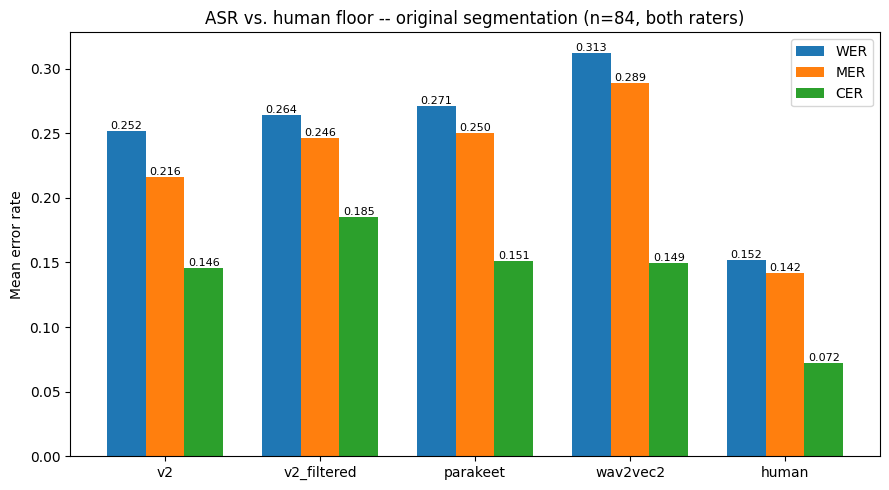

In [7]:
plot_with_floor(original_table, ["v2", "v2_filtered", "parakeet", "wav2vec2", "human"],
                "ASR vs. human floor -- original segmentation (n=84, both raters)",
                "../plots/interrater_vs_asr_original.png")

### Resegmented (windowed, 4s merge-gap) (n=102 hit recordings)

In [8]:
resegmented_table = combined_summary(RESEGMENTED_ROOT, ["whisper", "parakeet", "wav2vec2"], resegmented_hit_recordings)
resegmented_table

,wer_mean,mer_mean,cer_mean,wer_median,mer_median,cer_median,wer_pct_perfect
whisper,0.2480,0.2166,0.1398,0.1429,0.1429,0.0476,0.349
parakeet,0.2805,0.2596,0.1558,0.1429,0.1429,0.0513,0.329
wav2vec2,0.3230,0.3003,0.1489,0.2500,0.2500,0.0769,0.207
human,0.1608,0.1501,0.0763,0.1111,0.1111,0.0250,0.429


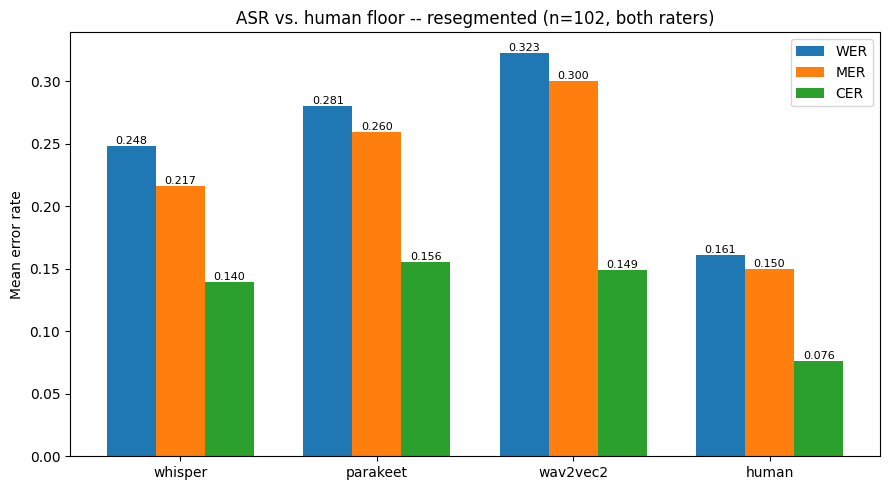

In [9]:
plot_with_floor(resegmented_table, ["whisper", "parakeet", "wav2vec2", "human"],
                "ASR vs. human floor -- resegmented (n=102, both raters)",
                "../plots/interrater_vs_asr_resegmented.png")

## Takeaway

The human-vs-human floor sits well below every ASR system on every metric, but the gap is a
meaningful multiple, not a rounding error: mean WER for the best ASR system (`v2`/`whisper`,
~0.248-0.252) is about **1.5-1.7x the inter-rater floor** (~0.152-0.161) on both segmentations,
and the same ratio (~1.6x) holds for CER. Globally, across all 182 recordings with a matched human
sheet (not just hits), the floor is WER 0.216 / MER 0.201 / CER 0.116 -- somewhat higher than the
hit-recording-only floor, suggesting the harder-to-align "miss" recordings are also harder for
humans to transcribe consistently (longer/more disfluent responses, presumably).

So current ASR error is real, not mostly measurement noise from imperfect ground truth -- but it's
also not arbitrarily far from what two trained humans achieve on the same material. That supports
pursuing the other improvement directions (targeted confidence-based trimming, model ensembling,
domain fine-tuning) with a concrete target in mind: closing roughly half the gap to the ~0.15-0.16
WER floor would already be a large, meaningful win, and fully matching it is the realistic ceiling
rather than 0.